# Develop an AI multi-agent workflow

In this notebook you will:

1. **Set up the environment to run an AI multi-agent system using a local configuration.**  
2. **Build an AI multi-agent system**.

## 0) Use case overview: a multi-agent e-commerce assistant

*Llama Wear This*, an online T-shirt store that wants to add an AI store assistant to its website, has been impressed with the results of your single-agent system.

Now, they would like to expand its capabilities. Their second most frequently asked question is: How long does shipping take to a specific city?

As their AI consultant, you propose building a multi-agent system, where specialized AI assistants handle specific tasks more efficiently and reliably.

This system will include:
* An **inventory assistant** to check which T-shirt colors are available.
* A **shipping assistant** to provide delivery information by city.
* A **supervisor agent** to coordinate these assistants and compose the final response for customers.

## 1) System setup

### 1.1) Install Ollama

**Run** the following cell to install Ollama in your Colab session:

In [ ]:
%%bash
set -e  # Stop execution if any command fails

# Update package lists quietly
sudo apt-get update -qq

# Install the compression utility needed by Ollama
sudo apt-get install -y -qq zstd

# Download and run the Ollama installer (suppress normal output)
curl -fsSL https://ollama.com/install.sh | sh > /dev/null


### 1.2) Start Ollama server and do a sanity check


**Run** the following cell to start Ollama server and do a sanity check:

In [ ]:
import subprocess
import time
import os

# 1. Start the server and redirect output to a log file so it doesn't clog your notebook
with open("ollama_server.log", "w") as f:
    subprocess.Popen(["ollama", "serve"], stdout=f, stderr=f)

# 2. Wait for the server to actually initialize
print("Waiting for Ollama server to start...")
time.sleep(10)

# 3. After 10 seconds, the server should be ready
print("Ollama server should now be ready.")

# 4. Verify the server is responding
!curl http://localhost:11434

### 1.3) Download LLM

**Run** the following cell to download the model you will use. This may take some time:

In [ ]:
!ollama pull qwen2.5:7b-instruct

### 1.4) Install required libraries

To use Langchain/LangGraph with Ollama, you will install the required packages via `pip`.

**Run** the following cell:

In [ ]:
!pip install langgraph langchain langchain-core langchain-ollama "pydantic==2.12.3"
!pip install -U langgraph-supervisor

## 2) Build an AI multi-agent

### 2.1) Create demo “databases”

Your agents will interact with structured data stored in simple tables:

- A **t-shirt inventory database** (which colours are sold).
- A **shipping database** (delivery availability and time by city).

**Run** the two following cells to see the mock databases:

In [ ]:
import pandas as pd

# Demo inventory table (acts like a tiny database)
tshirt_catalog = pd.DataFrame(
    {"colour": ["black", "white", "navy"],
     "price": [20, 20, 25],
     "stock": [3, 0, 5]}
)

tshirt_catalog

In [ ]:
shipping_times = pd.DataFrame(
    {"city": ["madrid", "barcelona", "santander"],
     "time": ["24h", "48h", "48h"]
    }
)

shipping_times

### 2.2) Define tools individual agents can use

In a multi-agent workflow, each specialized agent interacts with external data through **tools**.

You will define two tools, one for each of the specialized agents:

- **Inventory tool** → checks whether a requested T-shirt colour is available.
- **Shipping tool** → checks delivery availability and time for a given city.

> **Note:** Instead of returning free-form text, each tool in this workflow returns a **Python dictionary** containing explicit fields (such as availability, shipping status). Structured outputs make it easier for agents to reliably extract information.

**Run** the following cell to load the tools:

In [ ]:
# Import the decorator used to register agent tools
from langchain_core.tools import tool

# Tool to be used by inventory_agent
@tool
def check_tshirt_catalog(colour: str):
    """Check whether a t-shirt colour is available."""

    colour = colour.lower().strip()
    item = tshirt_catalog[tshirt_catalog["colour"] == colour]

    if item.empty:
        return {
            "colour": colour,
            "available": False,
        }

    price = item["price"].iloc[0] if "price" in item.columns else None

    return {
        "colour": colour,
        "available": True,
    }


# Tool to be used by shipping_agent
@tool
def check_shipping_times(city: str):
  """
  Checks shipping time to a specific city

  """

  city = city.lower().strip()
  ship_time = shipping_times[shipping_times["city"] == city]

  if ship_time.empty:
      return {"city": city, "ships": False, "time": None}
  else:
      return {"city": city, "ships": True, "time": ship_time["time"].iloc[0]}

### 2.3) Build individual specialized agents

You will create two specialized tool-using agents that follow a Reason + Act (ReAct) style:
- An **inventory agent**.

- A **shipping agent**.



#### 2.3.1) Create the chat model

You will be using the same model `qwen2.5:7b-instruct` for both agents.

**Run** the following cell to load the model:

In [ ]:
# Import the client class
from langchain_ollama import ChatOllama

# Create an instance configured to use a specific Ollama model
chat_model = ChatOllama(
    model="qwen2.5:7b-instruct",  # Which model to use on the Ollama server
    temperature=0,               # Typical range: 0–1 (lower = more deterministic)
)

#### 2.3.2) Define agent's prompt

The prompt defines the agent's responsibilities and boundaries, such as:

- Which tool it should use.  
- What information it should ignore.
- How it should report results.  

Without a clear prompt, an agent may:
- Skip tool usage.  
- Answer questions outside its role.  
- Hallucinate information.  

**Run** the following cell to create the prompts of the agents:


In [ ]:
# Prompt for inventory_agent

inventory_agent_prompt = """
You are the inventory agent for a t-shirt store.

Hard rules (must follow):
- You MUST call check_tshirt_catalog exactly once before answering.
- If you have not called the tool yet, do NOT write an answer. Your next step must be calling check_tshirt_catalog.
- Do NOT announce what you will do. Call the tool first.

The check_tshirt_catalog tool returns a Python dict with keys like:
- colour (string)
- available (boolean)

Your job:
- After calling the tool, read the result and reply to the supervisor with EXACTLY ONE sentence.
- If available=false, say we do NOT sell that colour.
- If available=true, say we sell that colour.
- Output EXACTLY one sentence stating ONLY whether we sell the colour. Nothing else.
- Your sentence must not contradict the tool's available value.


One minimal example (do not copy it literally):
Supervisor: Do you sell <COLOUR> t-shirts and how long to ship to <CITY>?.
Assistant: We sell <COLOUR> t-shirts. (or: We do not sell <COLOUR> t-shirts.)
"""


# Prompt for shipping_agent
shipping_agent_prompt = """
You are the shipping agent for a t-shirt store.

Hard rules (must follow):
- You MUST call check_shipping_times exactly once before answering.
- If you have not called the tool yet, do NOT write an answer. Your next step must be calling check_shipping_times.
- Do NOT announce what you will do (e.g., "We will check..."). Call the tool first.
- Do NOT transfer back to the supervisor until AFTER you have called the tool and produced your final sentence.

The check_shipping_times tool returns a Python dict with keys like:
- city (string)
- ships (boolean)
- time (string like "24h"/"48h" or null)

Your job:
- After calling the tool, read the result and reply to the supervisor in ONE short natural-language sentence.
- If ships=false, say we do NOT ship to that city.
- If ships=true, state the shipping time.
- Ignore product colour, stock, prices, and promotions.
- Your sentence must not contradict the tool's ships/time values.

One minimal example (do not copy it literally):
Supervisor: Check shipping time to <CITY>.
Assistant: (call check_shipping_times)
Assistant: Shipping to <CITY> takes <TIME>. (or: We do not ship to <CITY>.)
"""

#### 2.3.3) Define agent's name

The name uniquely identifies the agent inside the workflow graph. It allows the supervisor to:

- Delegate tasks to the correct agent.  
- Track which agent produced each result.  
- Coordinate multi-step reasoning.  

Without explicit names, the supervisor cannot reliably route tasks.

**Run** the following cell to register the names of the agents:

In [ ]:
inventory_agent_name = "inventory_agent"
shipping_agent_name = "shipping_agent"

#### 2.3.3) Combine previous components to create individual agents

To create individual agents, we combine:
- a list of registered **tools**: `inventory_agent_tools`/`shipping_agent_tools`,
- A **model**: `chat_model`,
- a **name**: `inventory_agent`/`shipping_agent`,
- a **prompt**: `inventory_agent_prompt`/`shipping_agent_prompt`.



**Fill in** the following cell to create the agents:
> Note: You may see a deprecation message suggesting to call `create_react_agent` from `langchain.agents`. You can safely ignore this, as calling `create_react_agent` from `langchain.agents` is deprecated from LangChain 1.0.

In [ ]:
# Import ReAct agent builder from LangGraph
from langgraph.prebuilt import create_react_agent

# List of available tools for inventory_agent
inventory_agent_tools = ## PLACE TOOLS ##

# List of available tools for shipping_agent
shipping_agent_tools = ## PLACE TOOLS ##

# Create inventory_agent using previously defined parameters
inventory_agent = create_react_agent(
    model=## FILL ## ,
    tools=## FILL ## ,
    name=## FILL ## ,
    prompt= ## FILL ##
)

# Create shipping_agent using previously defined parameters
shipping_agent = create_react_agent(
    model=## FILL ## ,
    tools=## FILL ## ,
    name=## FILL ## ,
    prompt= ## FILL ##
)



**Run** the following cells to check your agents:

In [ ]:
from langchain_core.messages import HumanMessage

# Construct the initial conversation state
inputs = {
    "messages": [
        # Provide the user's question
        HumanMessage(content="Do you sell white t-shirts?")
    ]
}

# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in inventory_agent.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")

In [ ]:
# Construct the initial conversation state
inputs = {
    "messages": [
        # Provide the user's question
        HumanMessage(content="Check shipping time to Madrid.")
    ]
}

# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in shipping_agent.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")

### 2.4) Build a supervisor agent

The supervisor acts as the **orchestrator** of the multi-agent system.

Instead of answering user questions directly, it:

- interprets the user request,  
- decides which specialized agent should handle each part,  
- delegates tasks sequentially,  
- collects the agents' responses,  
- composes the final answer.  

This separation of concerns allows each agent to remain simple and focused, while the supervisor manages the overall reasoning flow.


#### 2.4.1) Define supervisor's prompt

The supervisor's prompt teaches it how to:

- Interpret user requests.  
- Decide which agent should act first.  
- Determine when additional agents are needed.  
- Combine multiple agent outputs into a coherent final response.

The prompt typically specifies:

- **Routing rules** - e.g., when to call the inventory agent vs. the shipping agent.

- **Execution order** - agents are called sequentially rather than in parallel.

- **Information boundaries** - the supervisor must not access databases directly.

- **Composition policy** - how to merge agent responses into a final answer.

**Run** the following cell to create a the supervisor's prompt:

In [ ]:
supervisor_prompt = """
You are a supervisor for a t-shirt store managing two agents:
- inventory_agent: answers whether we sell a colour.
- shipping_agent: checks shipping time to a city.

Rules:
- If the user mentions a colour, you MUST ALWAYS call inventory_agent FIRST.
- If the user asks about shipping or delivery time and/or mentions a city, you MUST call shipping_agent.
- Treat these as shipping-time questions: "how long", "shipping time", "delivery time", "arrive", "when will it arrive", "ship to", "deliver to".
- NEVER ask the user for information that is already present in the user message.
- Assign work to one agent at a time. Do not call agents in parallel.
- Do not do database work yourself. Use agents.
- Your response must compile the information provided by inventory_agent and shipping_agent.

Interpretation:
- Treat agent statements like "we sell", "we have", "available" as the color being available.
- Treat statements like "we do not sell", "not available", "out of stock" as not available.

Composition policy:

- If the requested colour is NOT available but we ship to the city requested by the user: do NOT present shipping time as if that item can be shipped.
  State that the store does not sell that color and provide the user with shipping time to the requested city
  in case they are interested in other available colours.
- If the requested colour is NOT available and we do NOT ship to the requested location, just say that we do not sell that colour and do NOT include information about shipping.
- If the requested colour IS available, the user asked shipping time, and the store ships to that city, say that we do sell that colour and include the shipping time.
- If the requested colour IS available, the user asked shipping time, but the store does not ship to that location, include that information.
- Do NOT include shipping time unless the user explicitly asks about it.
- Keep final answer concise.

Few-shot examples:

Example A:
User: Do you sell red t-shirts and how long to ship to Barcelona?
(inventory_agent): No, we do not sell red t-shirts.
(shipping_agent): For Barcelona, shipping time is 48 hours.
Supervisor: I'm sorry, we don't currently sell red t-shirts. If you're interested in other available colours, shipping to Barcelona is 48 hours.

Example B:
User: Do you sell white t-shirts and how long to ship to Bilbao?
(inventory_agent): Yes, we do sell white t-shirts.
(shipping_agent): We do not ship to Bilbao.
Supervisor: We do sell white t-shirts! Unfortunately, we do not ship to Bilbao.

Example C:
User: Do you sell navy t-shirts and how long to ship to Santander?
(inventory_agent): Yes, we do sell navy t-shirts.
(shipping_agent): For Santander, shipping time is 48 hours.
Supervisor: We do sell navy t-shirts! Shipping to Santander is 48 hours.
"""

#### 2.4.2) Define list of agents the supervisor can call

When creating the supervisor, you need to explicitly provide the list of agents it is allowed to delegate tasks to.

  **Run** the following cell to create a the list of agents:



In [ ]:
list_of_agents = [inventory_agent, shipping_agent]

#### 2.4.3) Build the supervisor

You will build the supervisor agent using a preconfigured utility provided by LangGraph.

  **Run** the following cell to create the supervisor:


In [ ]:
# Import preconfigured utilities and tools
from langgraph_supervisor import create_supervisor, create_handoff_tool, create_forward_message_tool

# Create the agent
supervisor = create_supervisor(
    model=chat_model,
    agents=list_of_agents,
    prompt=supervisor_prompt,
    add_handoff_back_messages=True,  # determines whether a message is automatically added when control returns from a worker agent back to the supervisor
    output_mode="full_history",      # controls how much of the workflow’s message history is returned
).compile()

### 2.5) Visualise your workflow

You will compile the agents into a workflow graph and visualise its structure to check that it matches your intended design.

**Run** the following cell to plot your graph:

In [ ]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

### 2.6) Run the multi-agent!

You will execute the workflow and print intermediate steps to inspect agent interactions and tool calls.

First, you will define a function that allows you to visualise how agents use tools and interact with each other.

**Run** the following cell to create the function:

In [ ]:
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage

def _tool_call_name_args(tc):
    # dict-like tool call
    if isinstance(tc, dict):
        name = tc.get("name") or tc.get("function", {}).get("name")
        args = tc.get("args") or tc.get("function", {}).get("arguments")
        return name, args

    # object-like tool call
    name = getattr(tc, "name", None)
    args = getattr(tc, "args", None)
    fn = getattr(tc, "function", None)
    if fn is not None:
        name = name or getattr(fn, "name", None)
        args = args or getattr(fn, "arguments", None)
    args = args or getattr(tc, "arguments", None)
    return name, args


def stream_run(app, user_text: str):
    inputs = {"messages": [{"role": "user", "content": user_text}]}

    print("\n" + "=" * 80)
    print("USER:", user_text)
    print("=" * 80)

    seen = set()
    final_ai_text = None

    for event in app.stream(inputs, stream_mode="updates"):
        if not isinstance(event, dict):
            continue

        for node_name, update in event.items():
            if not isinstance(update, dict):
                continue

            for m in (update.get("messages") or []):
                mid = getattr(m, "id", None)
                key = (type(m).__name__, mid, getattr(m, "content", None), getattr(m, "name", None))
                if key in seen:
                    continue
                seen.add(key)

                if isinstance(m, HumanMessage):
                    print(f"\n[{node_name}] USER → {m.content}")

                elif isinstance(m, ToolMessage):
                    print(f"\n[{node_name}] TOOL RESULT ({m.name}):\n{m.content}")

                elif isinstance(m, AIMessage):
                    sender = m.name or node_name  # Prefer actual AI name

                    tool_calls = getattr(m, "tool_calls", None) or m.additional_kwargs.get("tool_calls", [])
                    if tool_calls:
                        print(f"\n[{sender}] CALLING TOOL:")
                        for tc in tool_calls:
                            name, args = _tool_call_name_args(tc)
                            print(f"  → {name} args={args}")
                    else:
                        if m.content:
                            print(f"\n[{sender}] MESSAGE:\n{m.content}")
                            final_ai_text = m.content


    print("\n" + "-" * 80)
    print("FINAL (last AI message observed):")
    print(final_ai_text)
    print("-" * 80 + "\n")

    return final_ai_text

You can use the above function `stream_run` to see how different agents call tools and iteract with each other after receiving a user input. `stream_run` requires two arguments:

- **app**, which, in your case, will be `supervisor`  
- **user_text**, which will be your request: "Do you sell black t-shirts and how long to ship to Madrid?".

Notice in the output how the supervisor calls the agents, which in turn call their respective tools to perform the required tasks. The agents then return their results to the supervisor.

> **Note:** Because this execution may take some time (aprox. 30 minutes), an example (**non-runable text cell**) call and its output are shown below.

```python
stream_run(supervisor, "Do you sell black t-shirts and how long to ship to Madrid?")
```

```txt
================================================================================
USER: Do you sell black t-shirts and how long to ship to Madrid?
================================================================================

[supervisor] USER → Do you sell black t-shirts and how long to ship to Madrid?

[supervisor] CALLING TOOL:
  → transfer_to_inventory_agent args=None

[supervisor] TOOL RESULT (transfer_to_inventory_agent):
Successfully transferred to inventory_agent

[inventory_agent] CALLING TOOL:
  → check_tshirt_catalog args={'colour': 'black'}

[inventory_agent] TOOL RESULT (check_tshirt_catalog):
{"colour": "black", "available": true}

[inventory_agent] MESSAGE:
We sell black t-shirts.

[inventory_agent] CALLING TOOL:
  → transfer_back_to_supervisor args=None

[inventory_agent] TOOL RESULT (transfer_back_to_supervisor):
Successfully transferred back to supervisor

[supervisor] CALLING TOOL:
  → transfer_to_shipping_agent args=None

[supervisor] TOOL RESULT (transfer_to_shipping_agent):
Successfully transferred to shipping_agent

[shipping_agent] CALLING TOOL:
  → check_shipping_times args={'city': 'Madrid'}

[shipping_agent] TOOL RESULT (check_shipping_times):
{"city": "madrid", "ships": true, "time": "24h"}

[shipping_agent] MESSAGE:
Shipping to Madrid takes 24 hours.

[shipping_agent] CALLING TOOL:
  → transfer_back_to_supervisor args=None

[shipping_agent] TOOL RESULT (transfer_back_to_supervisor):
Successfully transferred back to supervisor

[supervisor] MESSAGE:
We sell black t-shirts and shipping to Madrid is 24 hours.

--------------------------------------------------------------------------------
FINAL (last AI message observed):
We sell black t-shirts and shipping to Madrid is 24 hours.
--------------------------------------------------------------------------------

We sell black t-shirts and shipping to Madrid is 24 hours.
```


### 2.7) Add another agent

After testing the multi-agent system, *Llama Wear This* lets you know they would like to include active promotions for the requested colour in their response.

You will develop another specialized agent that will handle promotions and discounts for t-shirts of specific colours and incorporate it into your current workflow.

#### 2.7.1) Build a new agent

**Run** the following cell to create the promotions agent:

In [ ]:
# Create database for promotions agent
promos = pd.DataFrame(
    {"colour": ["black"],
     "promo": ["Buy 3, pay for 2"]
    }
)

promos


# Define tools for promotions agent
@tool
def check_promos(colour: str):
  """
  Checks whether a t-shirt for a specific colour has promos or discounts.
  """

  colour = colour.lower().strip()
  promo = promos[promos["colour"] == colour]

  if promo.empty:
      return {"colour": colour, "has_promo": False, "promo": None}
  else:
      return {"colour": colour, "has_promo": True, "promo": promo["promo"].iloc[0]}


# Create promotions agent
promos_agent = create_react_agent(
    model=chat_model,
    tools=[check_promos],
    name="promos_agent",
    prompt= """
You are the promotions agent for a t-shirt store.

Hard rules (must follow):
- You MUST call check_promos exactly once before answering.
- If you have not called the tool yet, do NOT write an answer. Your next step must be calling check_promos.
- Do NOT announce what you will do (e.g., "We will check..."). Call the tool first.
- Do NOT transfer back to the supervisor until AFTER you have called the tool and produced your final sentence.

The check_promos tool returns a Python dict with keys like:
- colour (string)
- has_promo (boolean)
- promo (string or null)

Your job:
- After calling the tool, read the result and reply to the supervisor in ONE short natural-language sentence.
- If has_promo=false, clearly say there is no promotion for that colour.
- If has_promo=true, clearly state the promotion.
- Only talk about promotions for the colour. Do NOT mention stock availability, shipping, or cities.
- Your sentence must not contradict the tool’s has_promo/promo values.

One minimal example (do not copy it literally):
Supervisor: Do you sell <COLOUR> t-shirts and how long to ship to <CITY>?
Assistant: (call check_promos)
Assistant: There is a promotion for <COLOUR> t-shirts: <PROMO>. (or: There is no promotion for <COLOUR> t-shirts.)
"""

)

#### 2.7.2) Define new supervisor's prompt

**Run** the following cell to define the supervisor's prompt:

In [ ]:
supervisor_prompt_2="""

You are a supervisor for a t-shirt store managing three agents:
- inventory_agent: answers whether we sell a colour.
- promos_agent: checks whether there is a promotion for a colour.
- shipping_agent: checks shipping time to a city.

Procedure (must follow in order, one agent at a time):
1) If the user mentions a t-shirt colour, call inventory_agent first.
2) If inventory_agent says we sell the colour, you must call promos_agent second.
3) Call shipping_agent third ONLY if the user explicitly asks about shipping or delivery time AND a city is present.

Rules:
- NEVER ask the user for information that is already present in the user message.
- Do not call agents in parallel.
- Do not do database work yourself. Use agents only.

Treat these as shipping-time questions:
"how long", "shipping time", "delivery time", "arrive", "when will it arrive", "ship to", "deliver to".

Delegation (focused instructions only):
- To inventory_agent: "Check whether we sell <COLOUR> t-shirts."
- To promos_agent: "Check promotions for <COLOUR> t-shirts."
- To shipping_agent: "Check shipping time to <CITY>."
Do not include unrelated parts of the user's message.

Interpretation:
- Treat statements like "we sell", "we have", "available" as the colour being available.
- Treat statements like "we do not sell", "not available", "out of stock" as not available.

Composition policy:
- Always state whether the requested colour is available (from inventory_agent).
- If the colour IS available and promos_agent reports a promotion, include the promotion.
- If the colour IS available and promos_agent reports no promotion, do not mention promos.
- Include shipping information ONLY if the user explicitly asked about shipping time:
  - include the shipping time if we ship there,
  - otherwise include "we do not ship to <CITY>".
- If the colour is NOT available, do not present shipping as if that item can be shipped.
  If the user asked shipping time, you may add:
  "If you're interested in other available colours, shipping to <CITY> is <TIME>."
- Keep final answer concise.

Few-shot examples (placeholders):

Example A:
User: Do you sell <COLOUR> t-shirts and how long to ship to <CITY>?
(inventory_agent): No, we do not sell <COLOUR> t-shirts.
(shipping_agent): Shipping to <CITY> takes <TIME>.
Supervisor: I'm sorry, we don't currently sell <COLOUR> t-shirts. If you're interested in other available colours, shipping to <CITY> is <TIME>.

Example B:
User: Do you sell <COLOUR> t-shirts and how long to ship to <CITY>?
(inventory_agent): Yes, we do sell <COLOUR> t-shirts.
(promos_agent): There is no promotion for <COLOUR> t-shirts.
(shipping_agent): We do not ship to <CITY>.
Supervisor: We do sell <COLOUR> t-shirts! Unfortunately, we do not ship to <CITY>.

Example C:
User: Do you sell <COLOUR> t-shirts and how long to ship to <CITY>?
(inventory_agent): Yes, we do sell <COLOUR> t-shirts.
(promos_agent): There is a promotion for <COLOUR> t-shirts: <PROMO>.
(shipping_agent): Shipping to <CITY> takes <TIME>.
Supervisor: We do sell <COLOUR> t-shirts! Promo: <PROMO>. Shipping to <CITY> takes <TIME>.
"""

#### 2.7.3) Update the workflow

**Fill in** the following cell to create your new supervisor:

In [ ]:
# Create supervisor with three individual agents
supervisor = create_supervisor(
    ## FILL WITH REQUIRED ARGS ##
).compile()

#### 2.7.4) Plot the new graph

You are going to plot the new graph. It should look like this:

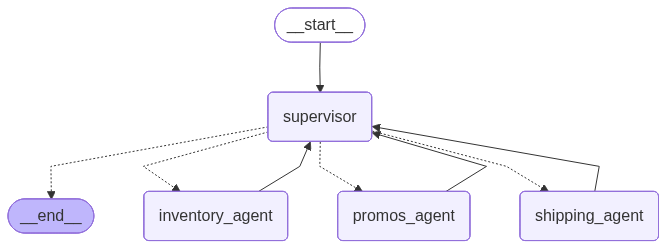

**Run** the next cell to get the new graph:

In [ ]:
# Display workflow with three agents
display(Image(supervisor.get_graph().draw_mermaid_png()))
